# DE on GLI3 knockout dataset

This tutorial demonstrates how to perform comprehensive differential expression analysis on the Gli3-KO dataset using the delnx package. We will cover pseudobulking, differential expression analysis, and visualization.

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Pseudobulking](#2-pseudobulking)
3. [Differential Expression Analysis](#3-differential-expression-analysis)
4. [Visualization](#4-visualization)
   - [Volcano Plots](#volcano-plots)
   - [Matrix & Dot Plots](#matrix--dot-plots)
   - [Violin Plots](#violin-plots)
5. [Gene Set Enrichment Analysis](#5-gene-set-enrichment-analysis-gsea)

## 1. Setup and Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import delnx as dx
from pathlib import Path

# Global Scanpy settings
sc.settings.verbosity = 2  # Show progress
sc.settings.set_figure_params(
    dpi=150,  # High-res output
    dpi_save=300,  # High-res when saving
    format="png",  # or 'pdf', 'svg'
    facecolor="white",  # or 'none' for transparent
    frameon=False,  # No outer frame
    vector_friendly=True,  # No rasterization warnings
    fontsize=10,  # Base font size
    figsize=(4, 4),  # Default figure size
    transparent=True,  # Transparent background if saving
)

mpl.rcParams.update(
    {
        "svg.fonttype": "none",  # Keep SVG text selectable
        "pdf.fonttype": 42,  # Embed fonts in PDFs (TrueType)
        "legend.fontsize": 6,
        "axes.titlesize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }
)

# Optional: remove scanpy's auto-show
sc.settings.autoshow = False

# Setup keys
sample_key = "batch"
group_key = "cell_type"
condition_key = "condition"

#### Load & Visualize data

In [2]:
# Load the dataset
adata_path = Path("data/GLI3_KO_45d.h5ad")
adata = sc.read(adata_path)

# Remove unwanted cell types
adata = adata[~adata.obs["cell_type"].isin(["ctx_ip", "ctx_ex", "ctx_npc"])]

# Make sure the metadata is formatted as categoricals
adata.obs[sample_key] = adata.obs["organoid"].astype(str)
adata.obs[sample_key] = pd.Categorical(adata.obs[sample_key], ordered=True)
adata.obs[group_key] = adata.obs["cell_type"].astype(str)
adata.obs[group_key] = pd.Categorical(adata.obs[group_key], ordered=True)
adata.obs[condition_key] = adata.obs["GLI3_KO"].astype(str)
adata.obs[condition_key] = pd.Categorical(adata.obs[condition_key], ordered=True)
# Store raw counts in a separate layer
adata.layers["counts"] = adata.X.copy()
# Store whole object under raw (this is needed for dotplots)
adata.raw = adata.copy()

In [3]:
# Some basic preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:02)


In [4]:
adata

AnnData object with n_obs × n_vars = 19844 × 18653
    obs: 'organoid', 'GLI3_KO', 'cell_type', 'batch', 'condition'
    uns: 'log1p'
    obsm: 'pca', 'umap'
    layers: 'counts'

[<Axes: title={'center': 'condition'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>]

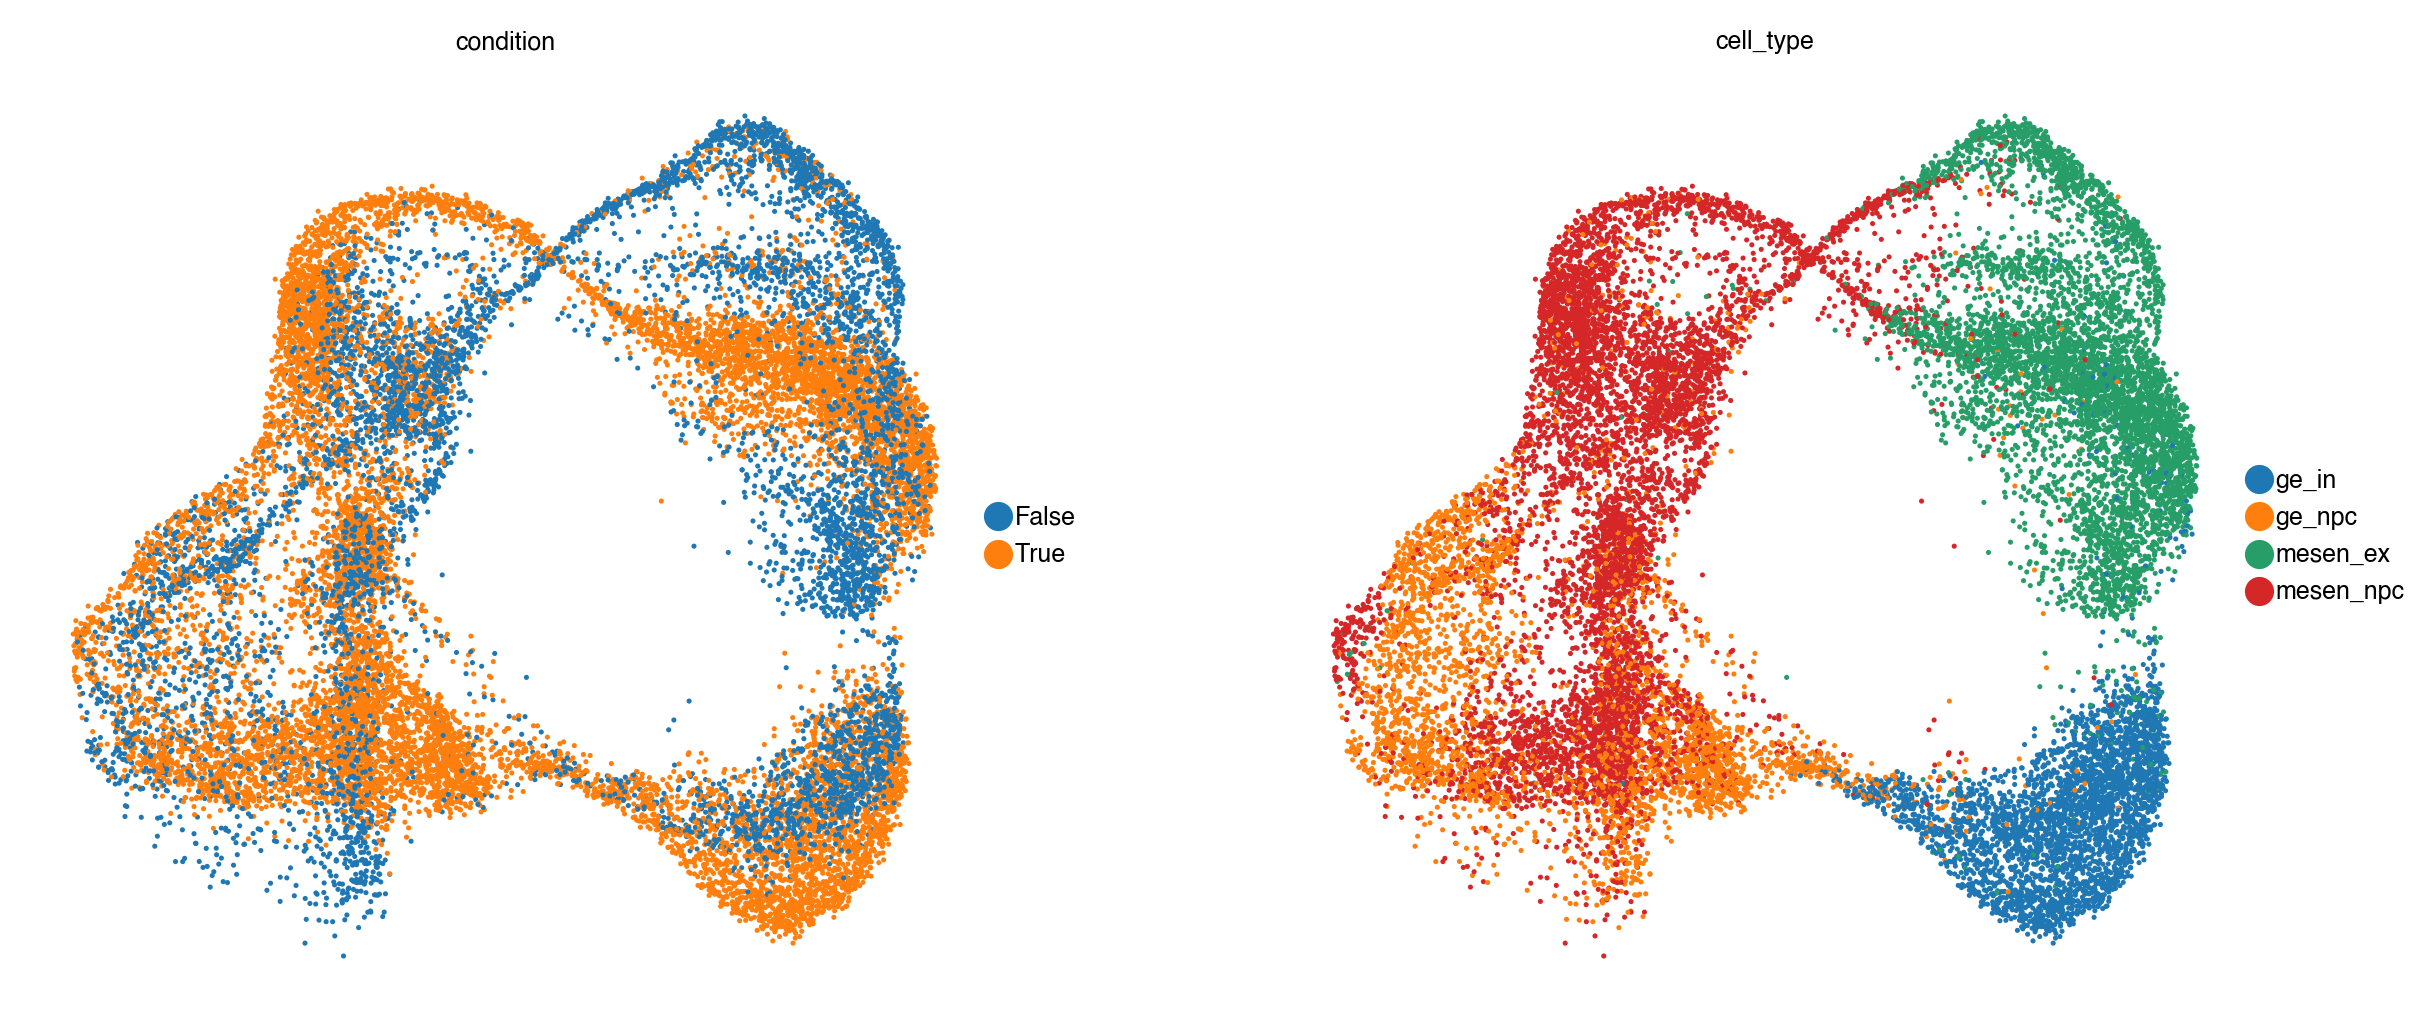

In [5]:
sc.pl.umap(adata, color=[condition_key, group_key])

#### Filter out lowly detected genes

Before downstream analysis, we remove genes with very low overall expression across all cells.

In [6]:
# Filter genes: keep those with total counts above the 25th percentile
from scipy import sparse
total_counts = np.array(adata.layers["counts"].sum(axis=0)).flatten()
threshold = np.percentile(total_counts[total_counts > 0], 25)
keep_mask = total_counts > threshold
print(f"Keeping {keep_mask.sum()} / {len(keep_mask)} genes (threshold: {threshold:.0f} counts)")

Keeping 12086 / 18653 genes (threshold: 92 counts)


In [7]:
adata = adata[:, keep_mask].copy()

## 2. Pseudobulking

Pseudobulking is a common preprocessing step in single-cell differential expression analysis. Instead of analyzing individual cells—which introduces challenges due to sparsity, high variability, and non-independence—we aggregate expression values across biologically meaningful groups, such as cell types and samples.

In this step, we:

1. **Group cells** by a combination of categories (e.g., `cell_type`, `sample`, `condition`).
2. **Sum or average** the raw counts for each gene across all cells in each group.
3. **Construct a pseudobulk matrix**, where each column corresponds to one group and each row to a gene.

This transforms sparse single-cell data into a bulk-like format that can be analyzed using well-established bulk RNA-seq differential expression tools such as **edgeR**, **DESeq2**, or **limma-voom**

In [8]:
adata_pb = dx.pp.pseudobulk(
    adata,
    sample_key=sample_key,  # Sample key for pseudobulk aggregation (the biological replicate)
    group_key=group_key,  # Group key for pseudobulk aggregation
    layer="counts",  # Layer to use for pseudobulk aggregation, e.g. "counts" or None for adata.X
    mode="sum",
)

print(adata_pb)

AnnData object with n_obs × n_vars = 28 × 12086
    obs: 'psbulk_replicate', 'cell_type', 'organoid', 'GLI3_KO', 'batch', 'condition', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'


## 3. Differential Expression Analysis

In [9]:
# Compute size factors
dx.pp.size_factors(adata_pb, method="ratio")

In [11]:
# Run per-cell-type negative binomial DE
results = dx.tl.grouped(
    dx.tl.nb_de,
    adata_pb,
    group_key=group_key,
    condition_key=condition_key,
    reference="False",
    contrast="condition[T.True]",
)

INFO     Running DE for group: ge_in                                                                               
INFO     Fitting 12086 genes with 2 coefficient(s) (batch_size=512)                                                


Fitting GLMs: 100%|██████████| 24/24 [00:07<00:00,  3.27it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


INFO     Running DE for group: ge_npc                                                                              
INFO     Fitting 12086 genes with 2 coefficient(s) (batch_size=512)                                                


Fitting GLMs: 100%|██████████| 24/24 [00:03<00:00,  7.89it/s]

...

Fitting GLMs: 100%|██████████| 24/24 [00:03<00:00,  7.80it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


INFO     Running DE for group: mesen_npc                                                                           
INFO     Fitting 12086 genes with 2 coefficient(s) (batch_size=512)                                                


Fitting GLMs: 100%|██████████| 24/24 [00:02<00:00,  8.20it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


In [12]:
results.head()

,feature,log2fc,coef,stat,pval,padj,group
0,LHX8,8.398307,5.821263,290.310323,1.550281e-10,0.000007,ge_in
1,SFTA3,9.072671,6.288696,255.404138,3.550870e-10,0.000009,ge_in
2,LHX6,7.450785,5.164491,132.413622,2.269491e-08,0.000274,ge_in
3,SOX6,2.647630,1.835197,119.430943,4.282508e-08,0.000414,ge_in
4,MEIS2,-2.522473,-1.748445,110.013110,7.068006e-08,0.000479,ge_in


## 4. Visualization

Once differential expression analysis has been performed, it's important to visualize the results to interpret and communicate key findings.

We explore the results at multiple levels:

- **Volcano plots** to visualize the magnitude and significance of gene-level changes.
- **Matrix plots** and **Dot plots** to summarize the expression of differentially expressed genes across multiple conditions or groups.
- **Violin plots** to compare selected genes across specific conditions and cell types.

#### Label DE genes

We use `get_de_genes` to label genes as upregulated, downregulated, or not significant based on effect size and p-value thresholds.

In [13]:
from delnx._utils import get_de_genes

# Label DE genes and get per-group gene lists
de_genes_dict, results = get_de_genes(
    results,
    group_key="group",
    effect_key="log2fc",
    pval_key="pval",
    effect_thresh=2,
    pval_thresh=0.05,
    return_labeled_df=True,
)

In [14]:
results.head(10)

,feature,log2fc,coef,stat,pval,padj,group,-log10(pval),significant
0,LHX8,8.398307,5.821263,290.310323,1.550281e-10,0.000007,ge_in,9.809589,Up
1,SFTA3,9.072671,6.288696,255.404138,3.550870e-10,0.000009,ge_in,9.449665,Up
2,LHX6,7.450785,5.164491,132.413622,2.269491e-08,0.000274,ge_in,7.644072,Up
3,SOX6,2.647630,1.835197,119.430943,4.282508e-08,0.000414,ge_in,7.368302,Up
4,MEIS2,-2.522473,-1.748445,110.013110,7.068006e-08,0.000479,ge_in,7.150703,Down
5,CDCA7L,-3.146040,-2.180669,90.405516,2.300047e-07,0.001010,ge_in,6.638263,Down
6,C12orf75,1.648706,1.142796,86.331484,3.022945e-07,0.001217,ge_in,6.519570,NS
7,CALB2,-2.726589,-1.889927,84.480440,3.435467e-07,0.001277,ge_in,6.464014,Down
8,MPPED2,-1.181557,-0.818993,77.860964,5.542778e-07,0.001913,ge_in,6.256273,NS
9,PDE5A,-3.828855,-2.653960,74.391434,7.224100e-07,0.002181,ge_in,6.141216,Down


#### Plot volcano plots

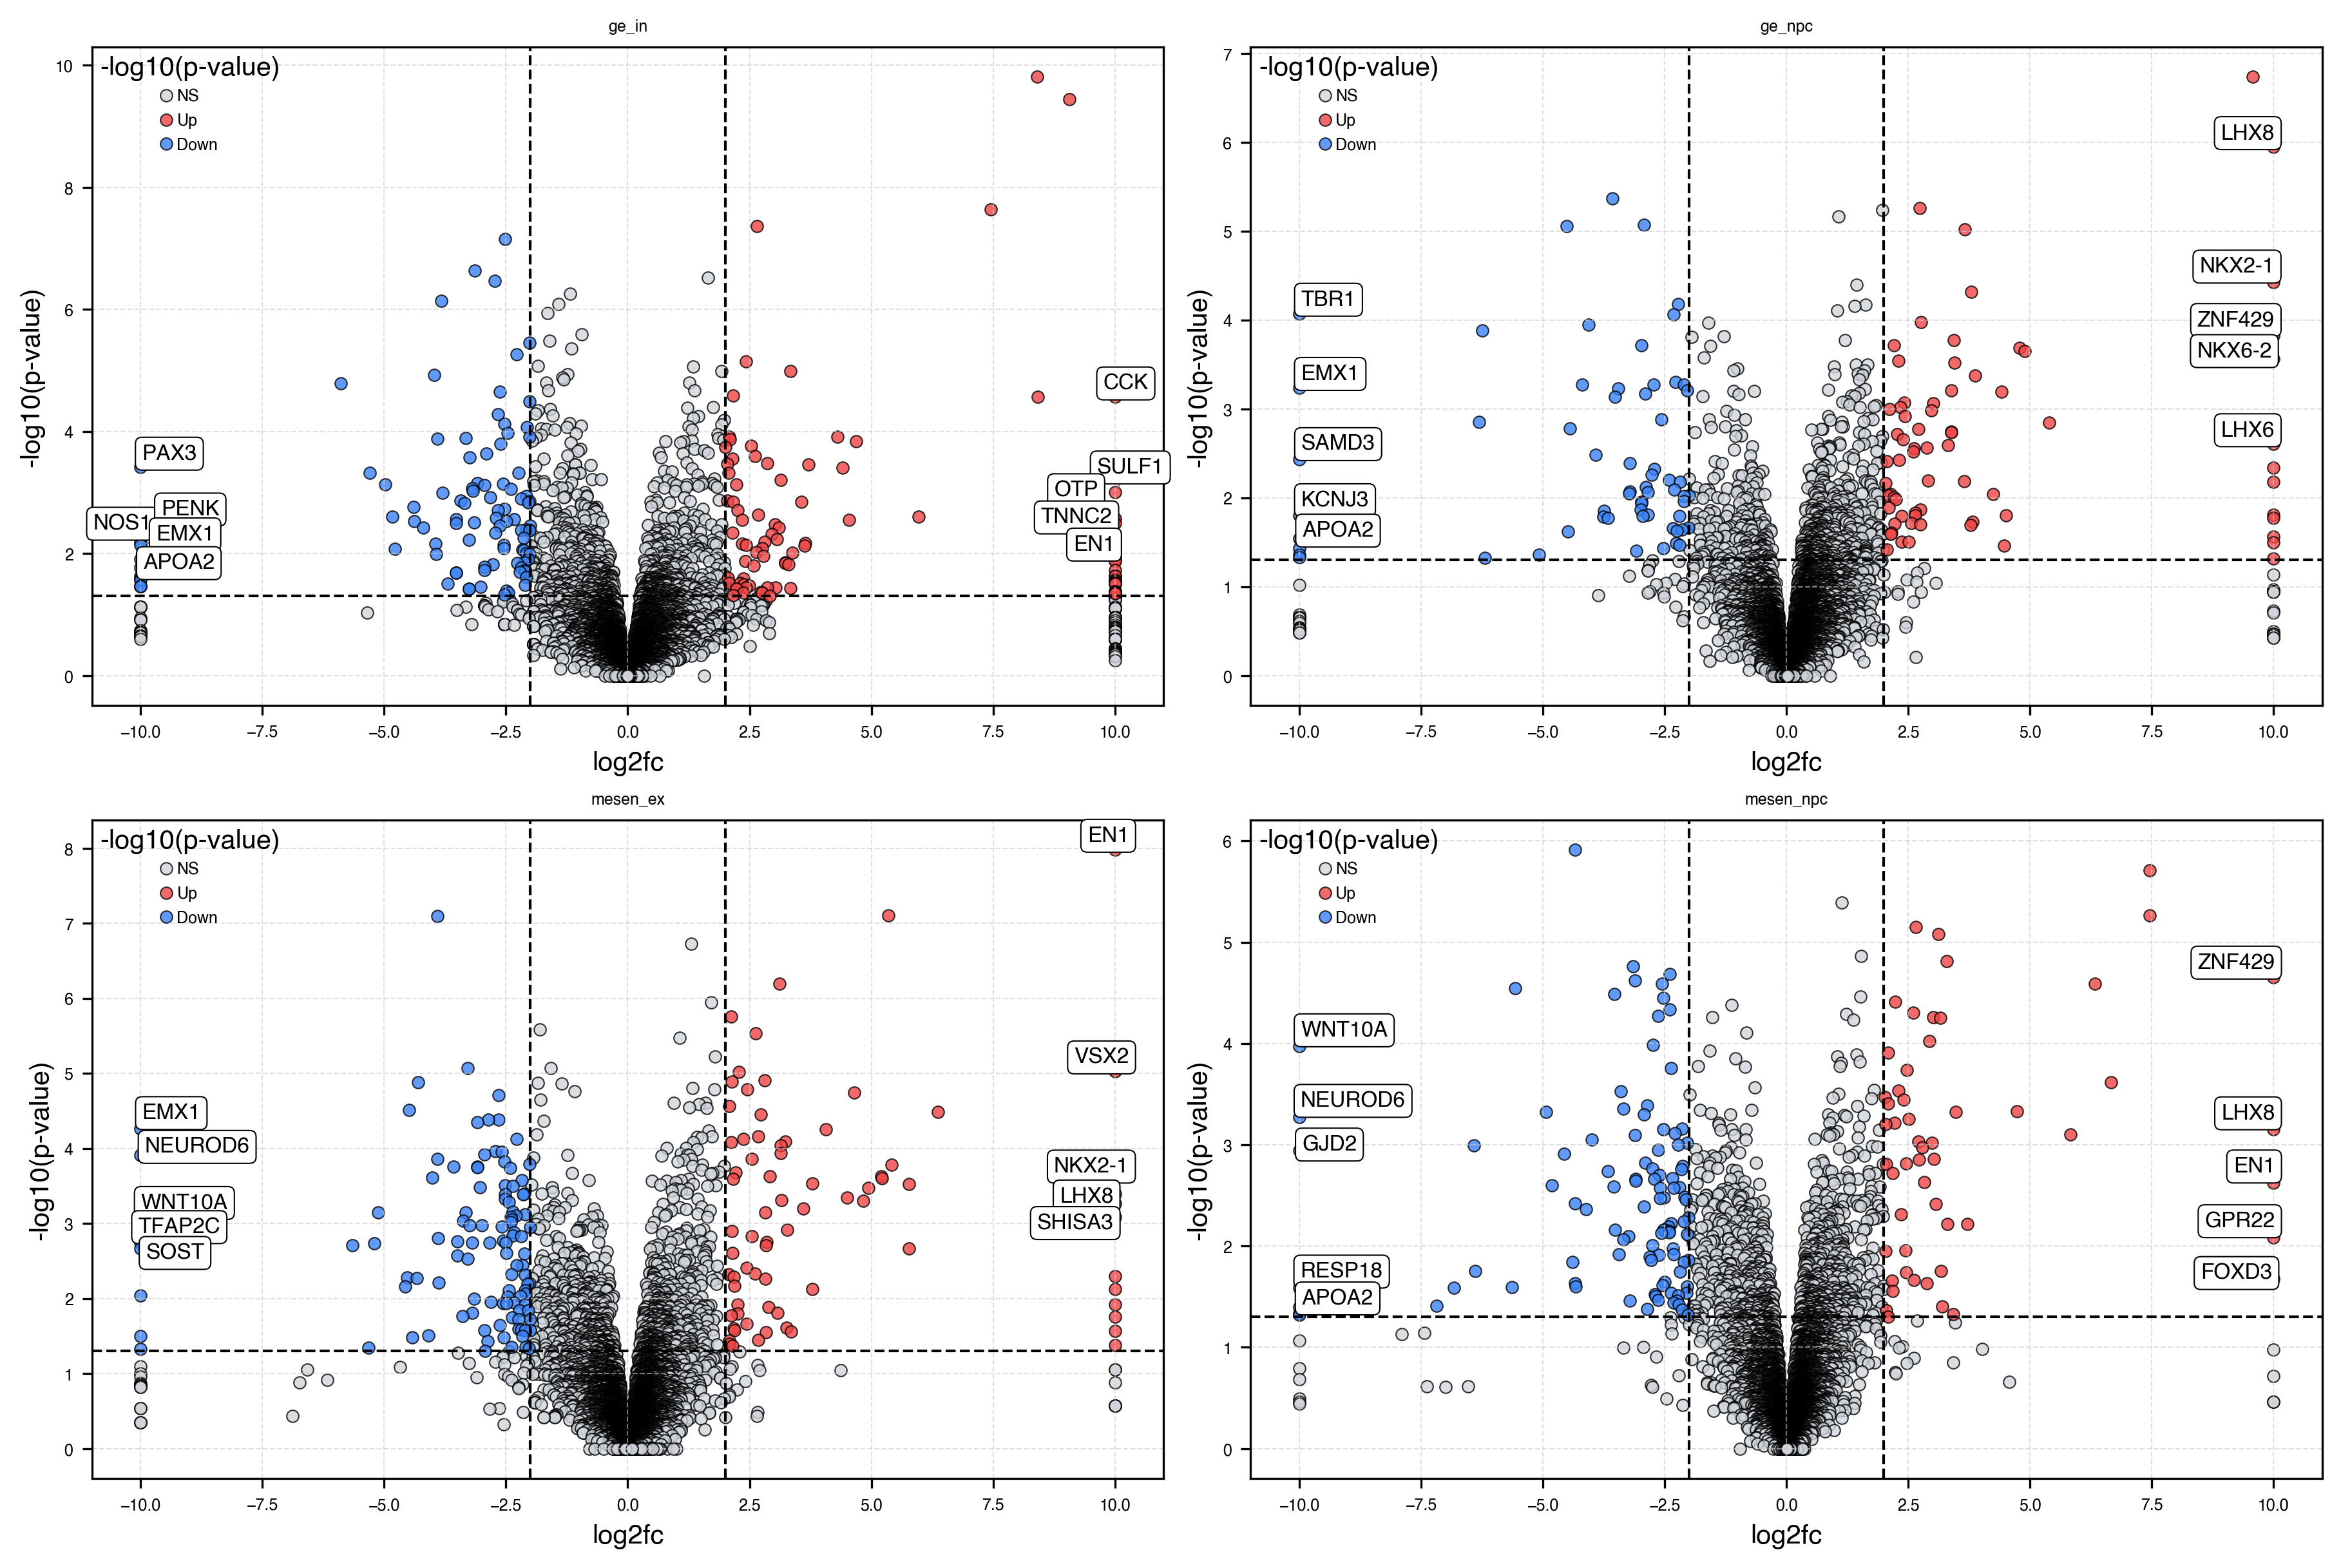

In [15]:
# Select groups to show
groups_to_plot = ["ge_in", "ge_npc", "mesen_ex", "mesen_npc"]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), constrained_layout=True)
axs = axs.flatten()

for i, group in enumerate(groups_to_plot):
    ax = axs[i]
    de_df = results[results["group"] == group].copy()
    dx.pl.volcanoplot(
        de_df,
        effect_thresh=2,
        pval_thresh=0.05,
        label_top=5,
        ax=ax,
        show=False,
    )
    ax.set_title(group)

# Remove empty axes if any
for j in range(len(groups_to_plot), len(axs)):
    fig.delaxes(axs[j])

plt.show()

#### Plot matrix/dotplots

In [16]:
top_up_per_group = (
    results[results["significant"] == "Up"]  # only upregulated genes
    .drop_duplicates(subset=["group", "feature"], keep="first")  # remove group-feature duplicates
    .sort_values(["group", "log2fc"], ascending=[True, False])  # sort by group and descending log2fc
)

In [17]:
top_up_per_group.head()

,feature,log2fc,coef,stat,pval,padj,group,-log10(pval),significant
34,CCK,10.0,23.319647,38.317248,0.000027,0.014874,ge_in,4.563734,Up
157,SULF1,10.0,22.155796,17.459695,0.000995,0.093665,ge_in,3.002316,Up
227,OTP,10.0,21.681268,13.424596,0.002687,0.161615,ge_in,2.570812,Up
245,TNNC2,10.0,20.583639,12.839357,0.003145,0.176984,ge_in,2.502397,Up
316,EN1,10.0,20.596160,10.691634,0.005808,0.242498,ge_in,2.235969,Up


In [18]:
marker_dict = top_up_per_group[["feature", "group"]].groupby("group")["feature"].apply(list).to_dict()

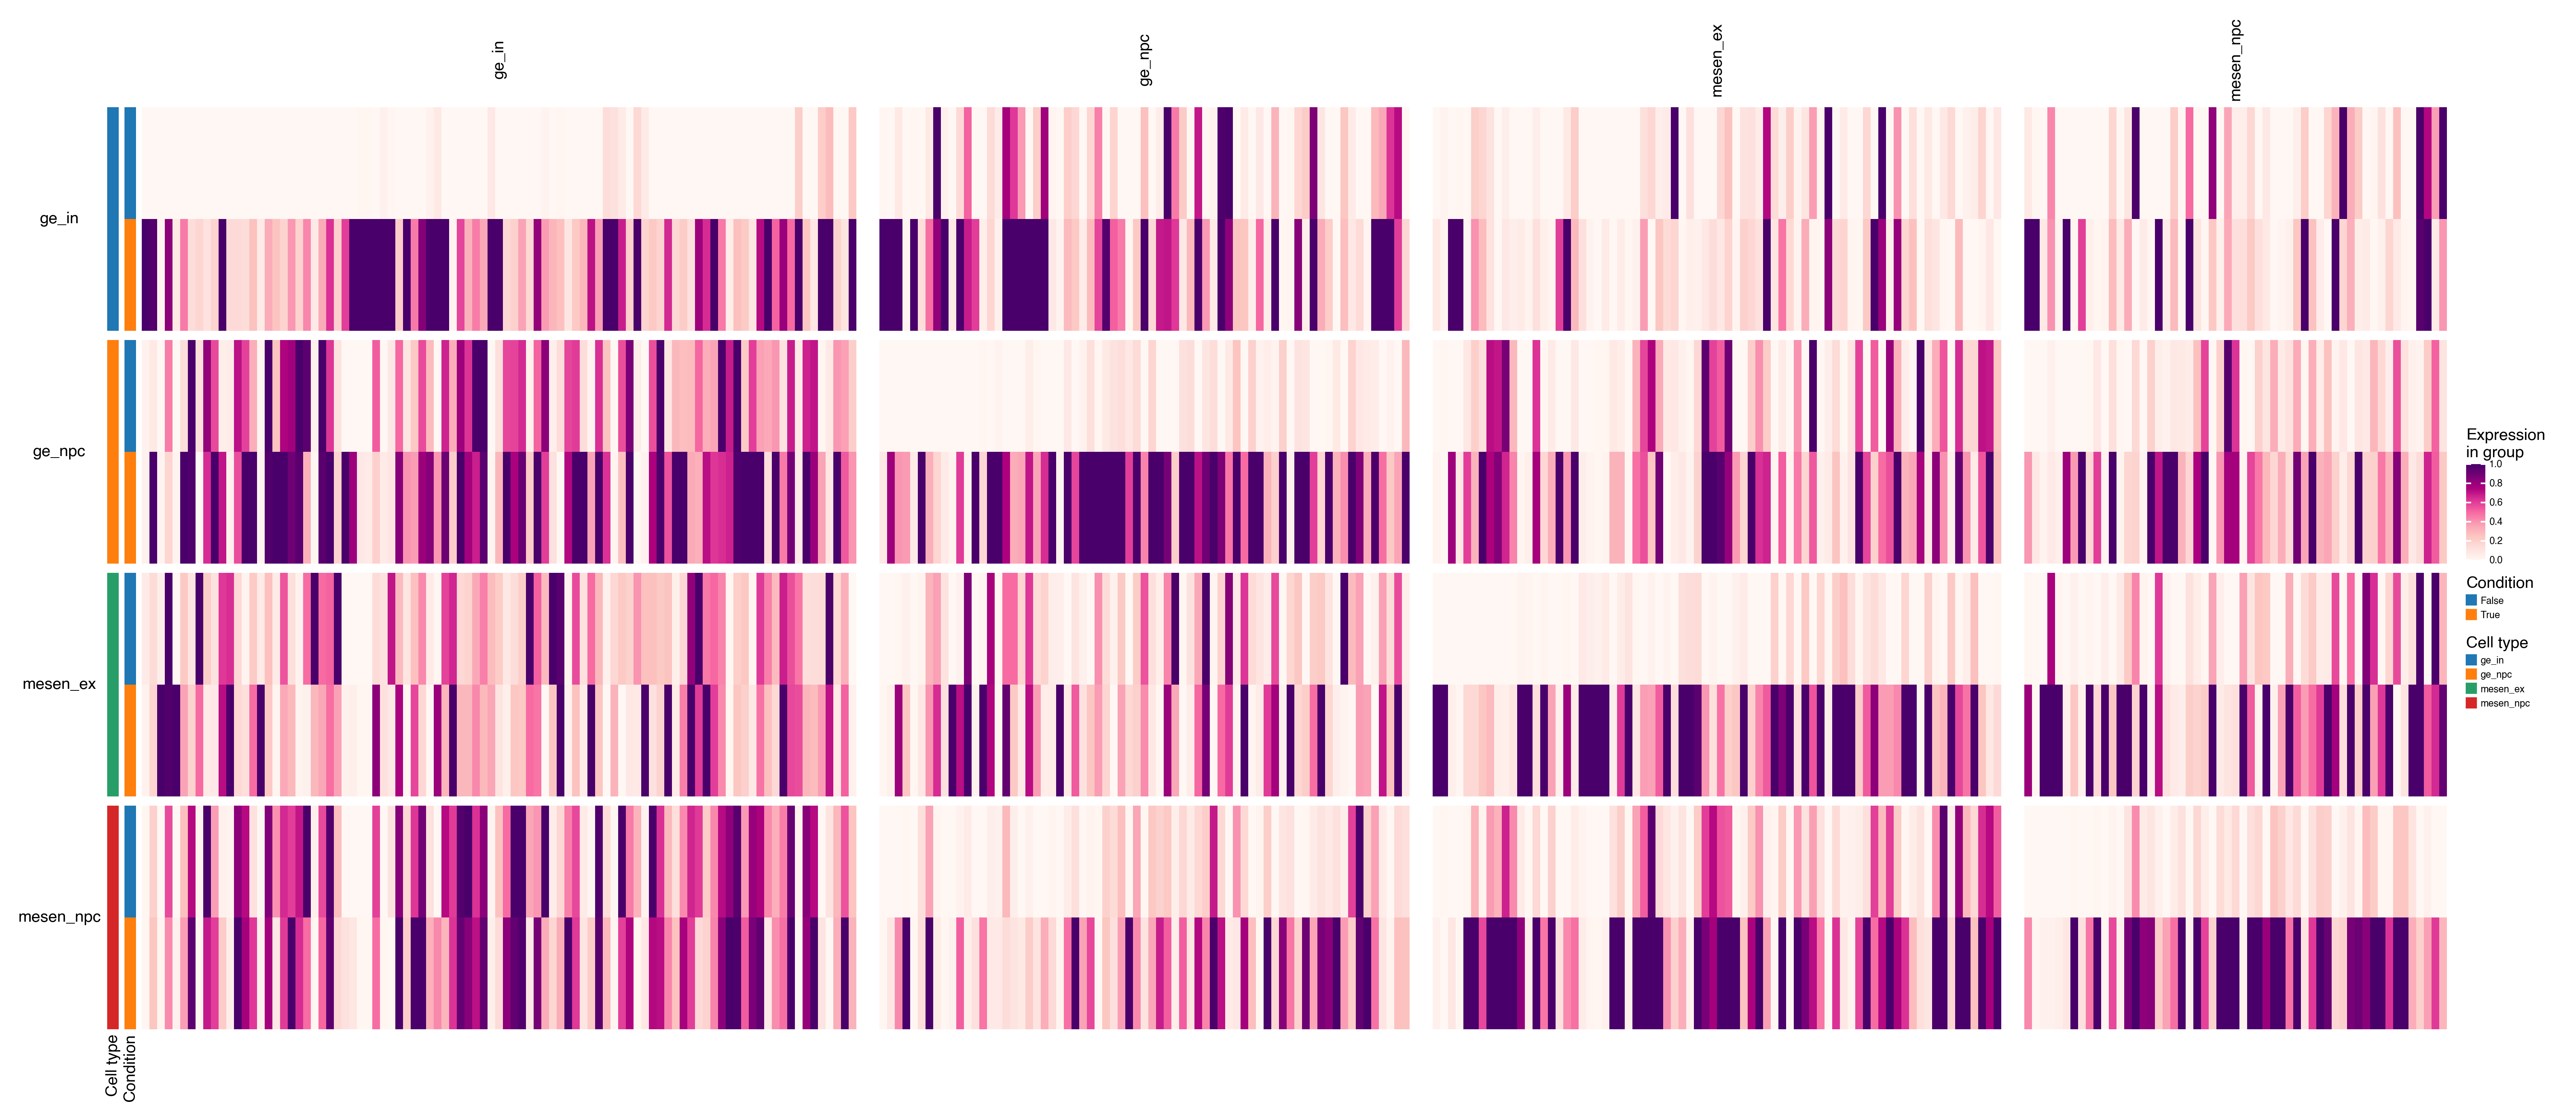

In [19]:
dx.pl.matrixplot(
    adata,
    markers=marker_dict,
    groupby=[group_key, condition_key],
    group_names=["Cell type", "Condition"],
    row_grouping=[group_key],
    column_grouping=True,
    cmap="RdPu",
    scale=True,
    width=20,
    height=8,
    show_legends=True,
    show_column_names=True,
    show_row_names=True,
)

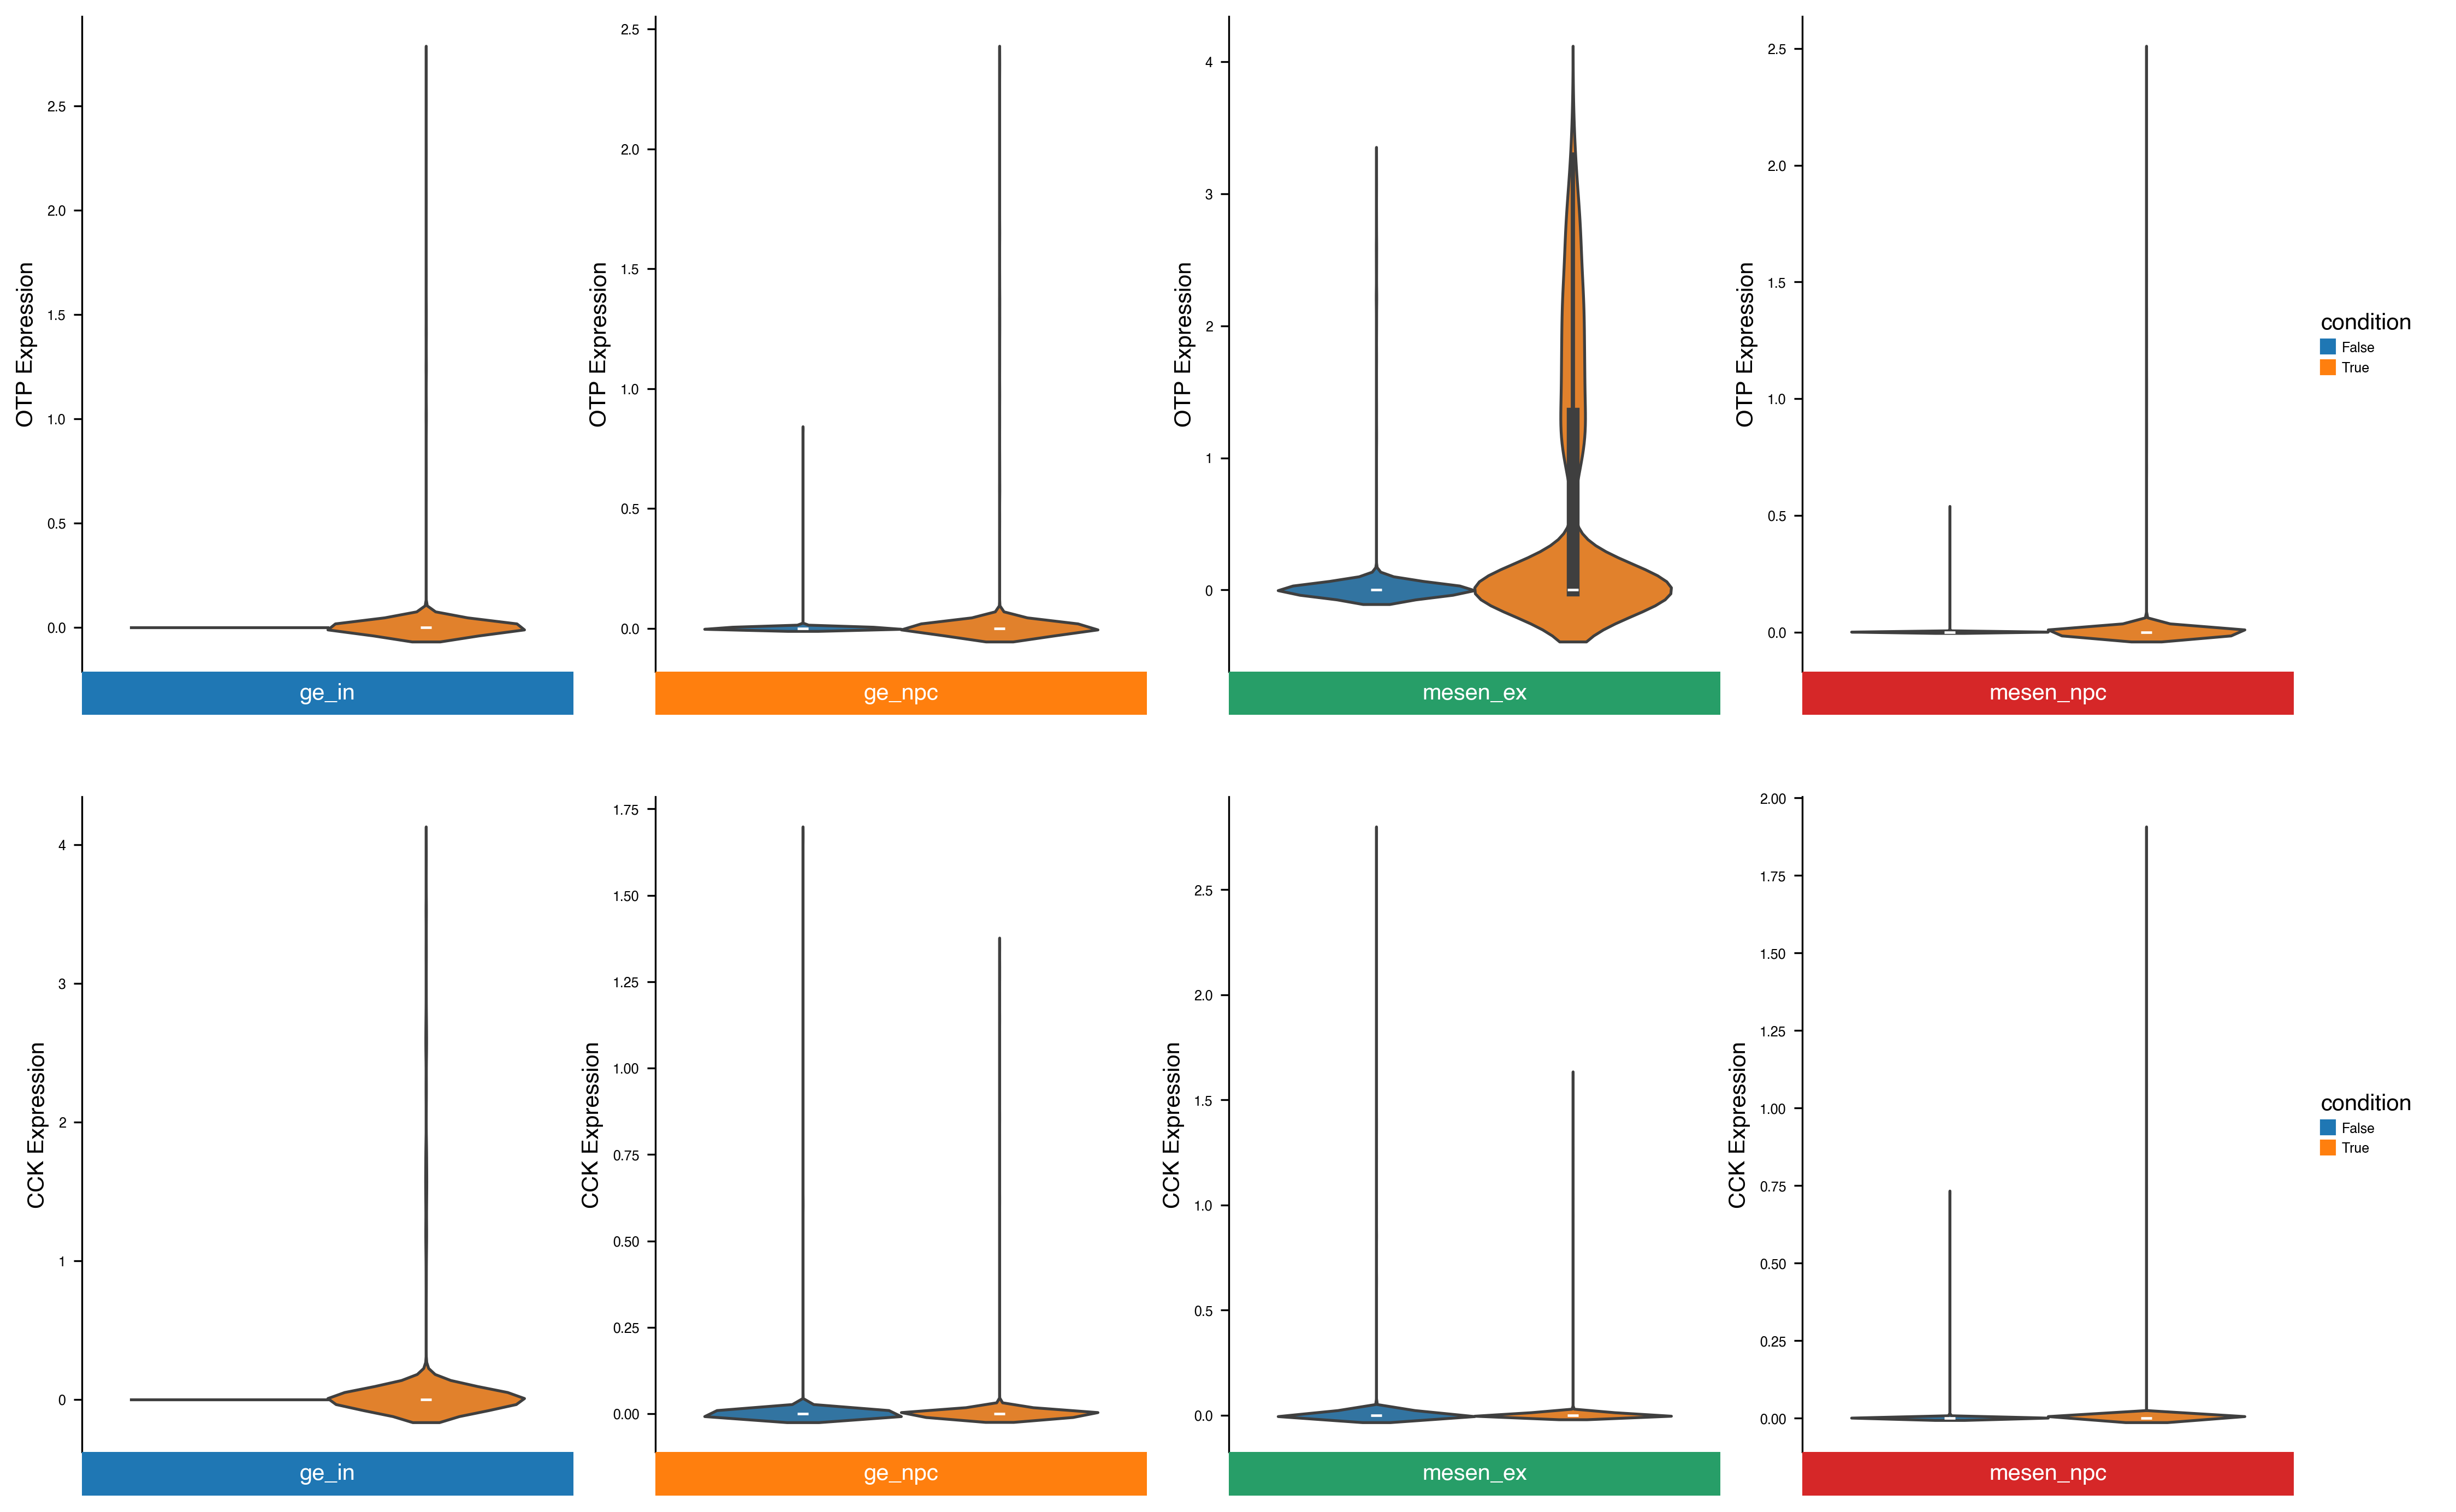

In [20]:
dx.pl.violinplot(adata, genes=["OTP", "CCK"], groupby=group_key, splitby=condition_key, use_raw=False, flip=True)

#### Intersect differentially expressed genes

In [21]:
# Extract all "up" gene sets from the dictionary (already computed above)
up_gene_sets = [set(v["up"]) for v in de_genes_dict.values()]

# Compute the intersection of all sets
common_up_genes = list(set.intersection(*up_gene_sets))
print(f"Common upregulated genes across all groups: {len(common_up_genes)}")

Common upregulated genes across all groups: 6


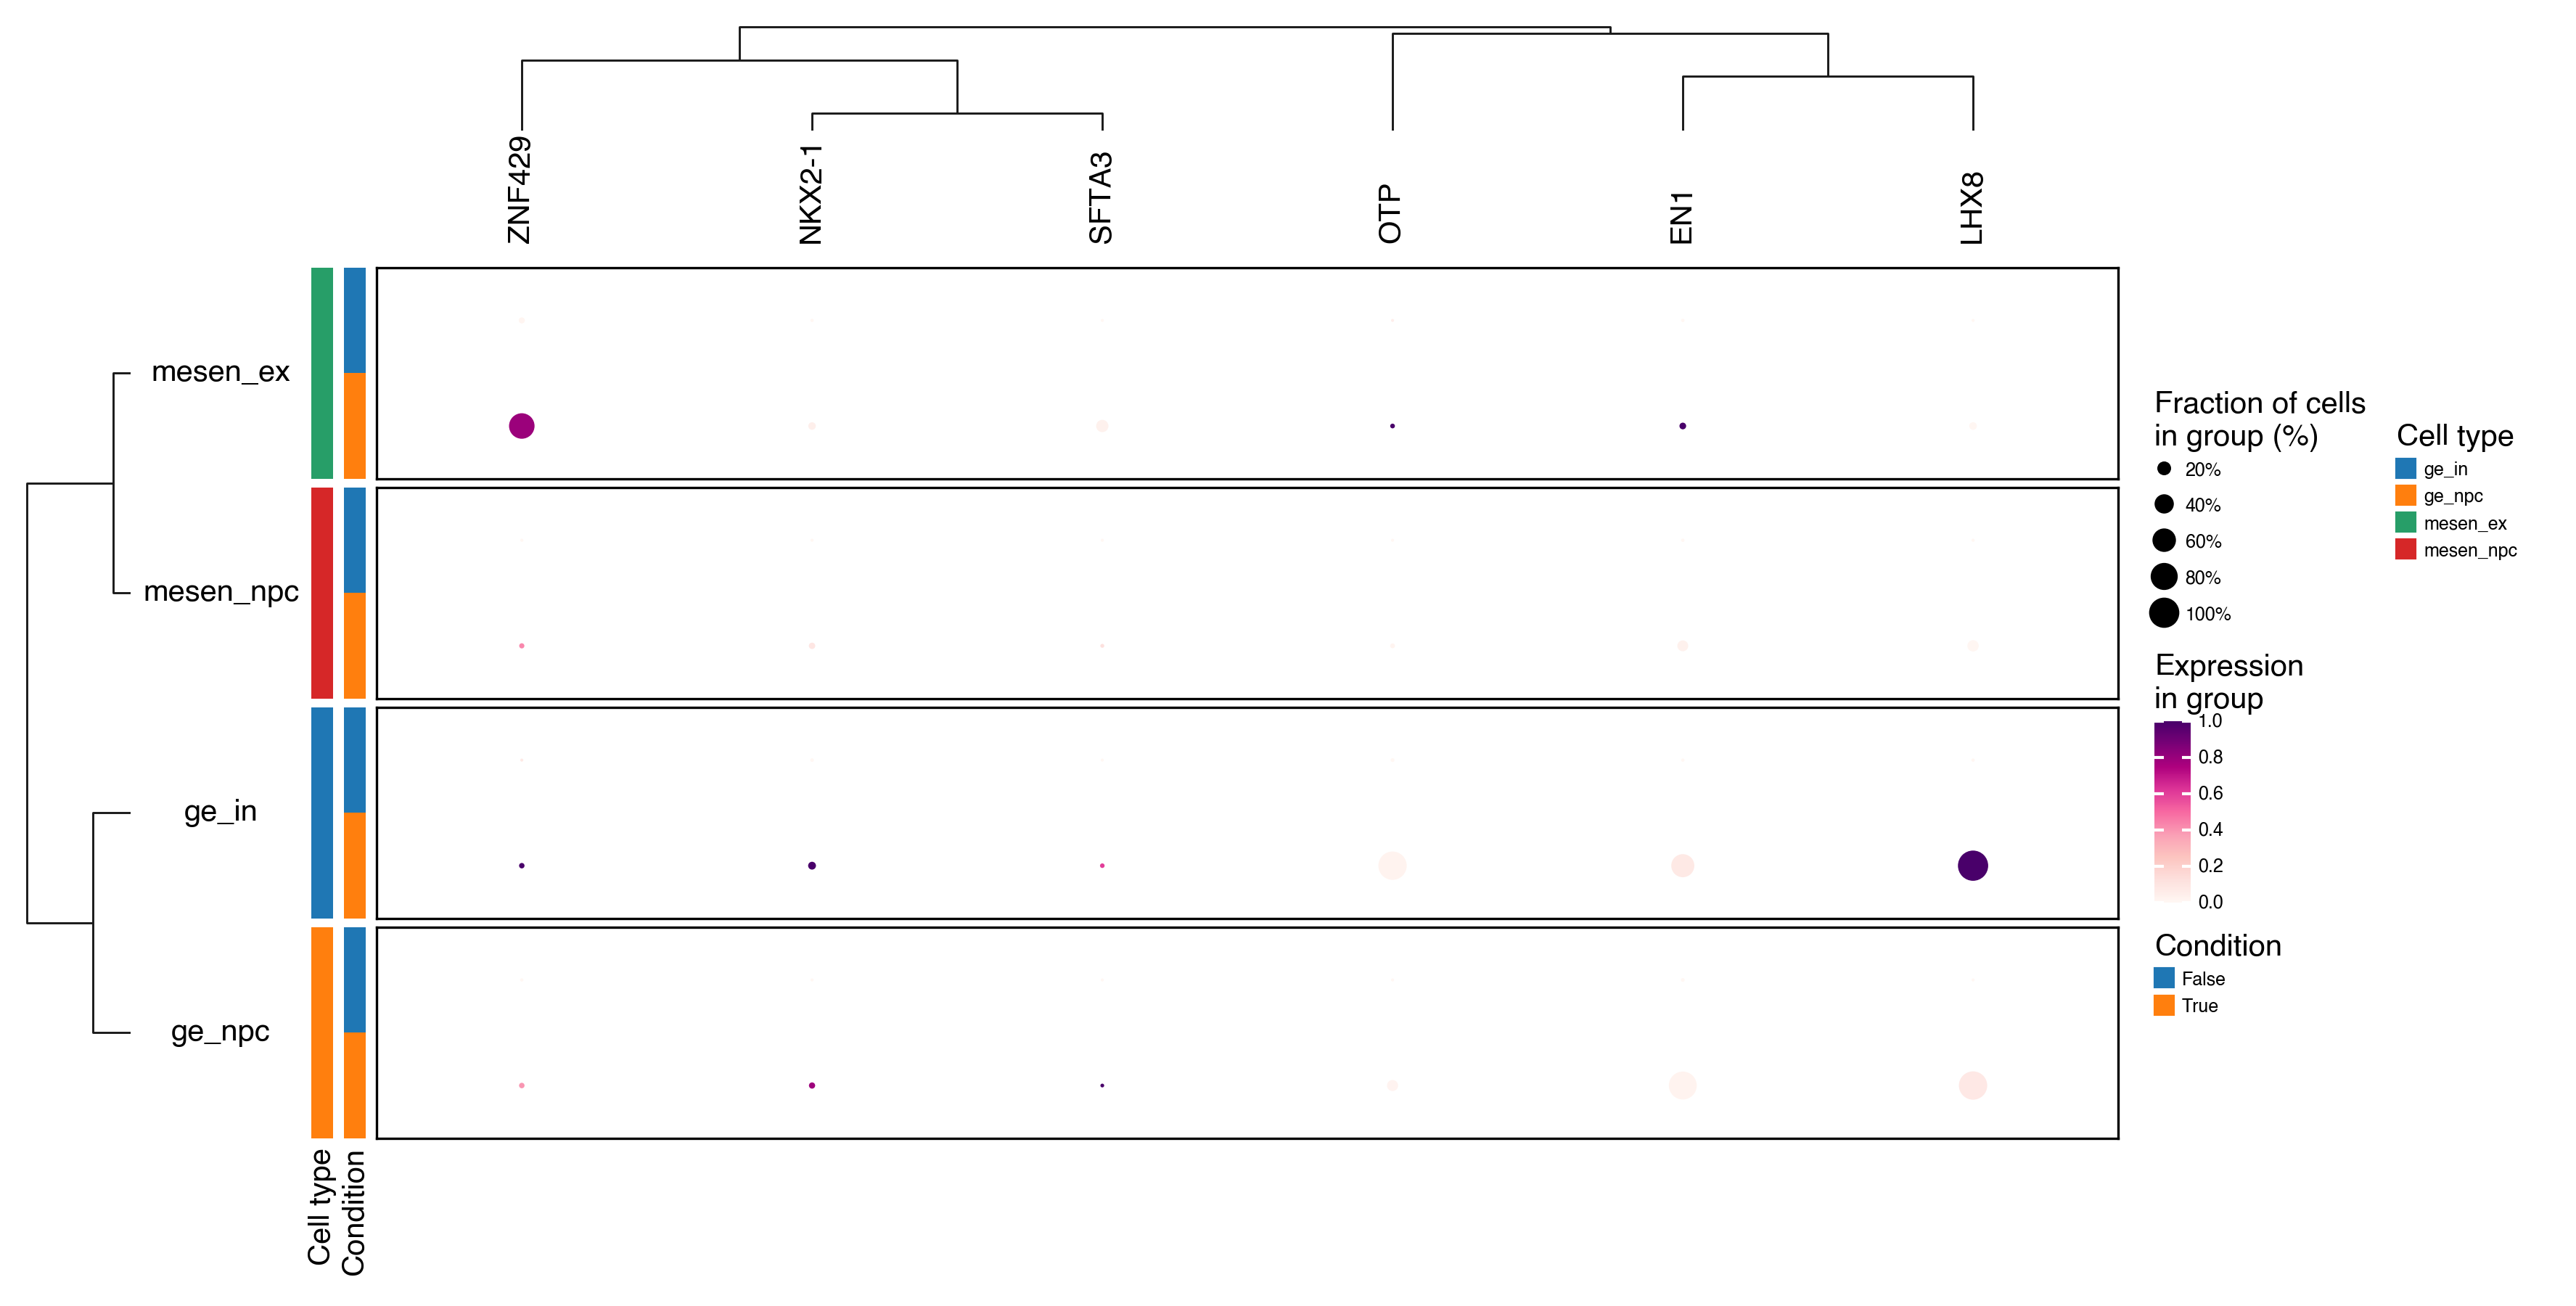

In [22]:
dx.pl.dotplot(
    adata,
    markers=common_up_genes,
    groupby=[group_key, condition_key],
    group_names=["Cell type", "Condition"],
    row_grouping=[group_key],
    column_grouping=True,
    dendrograms=["left", "top"],
    cmap="RdPu",
    scale=True,
    width=8,
    height=4,
    show_legends=True,
    show_column_names=True,
    show_row_names=True,
)

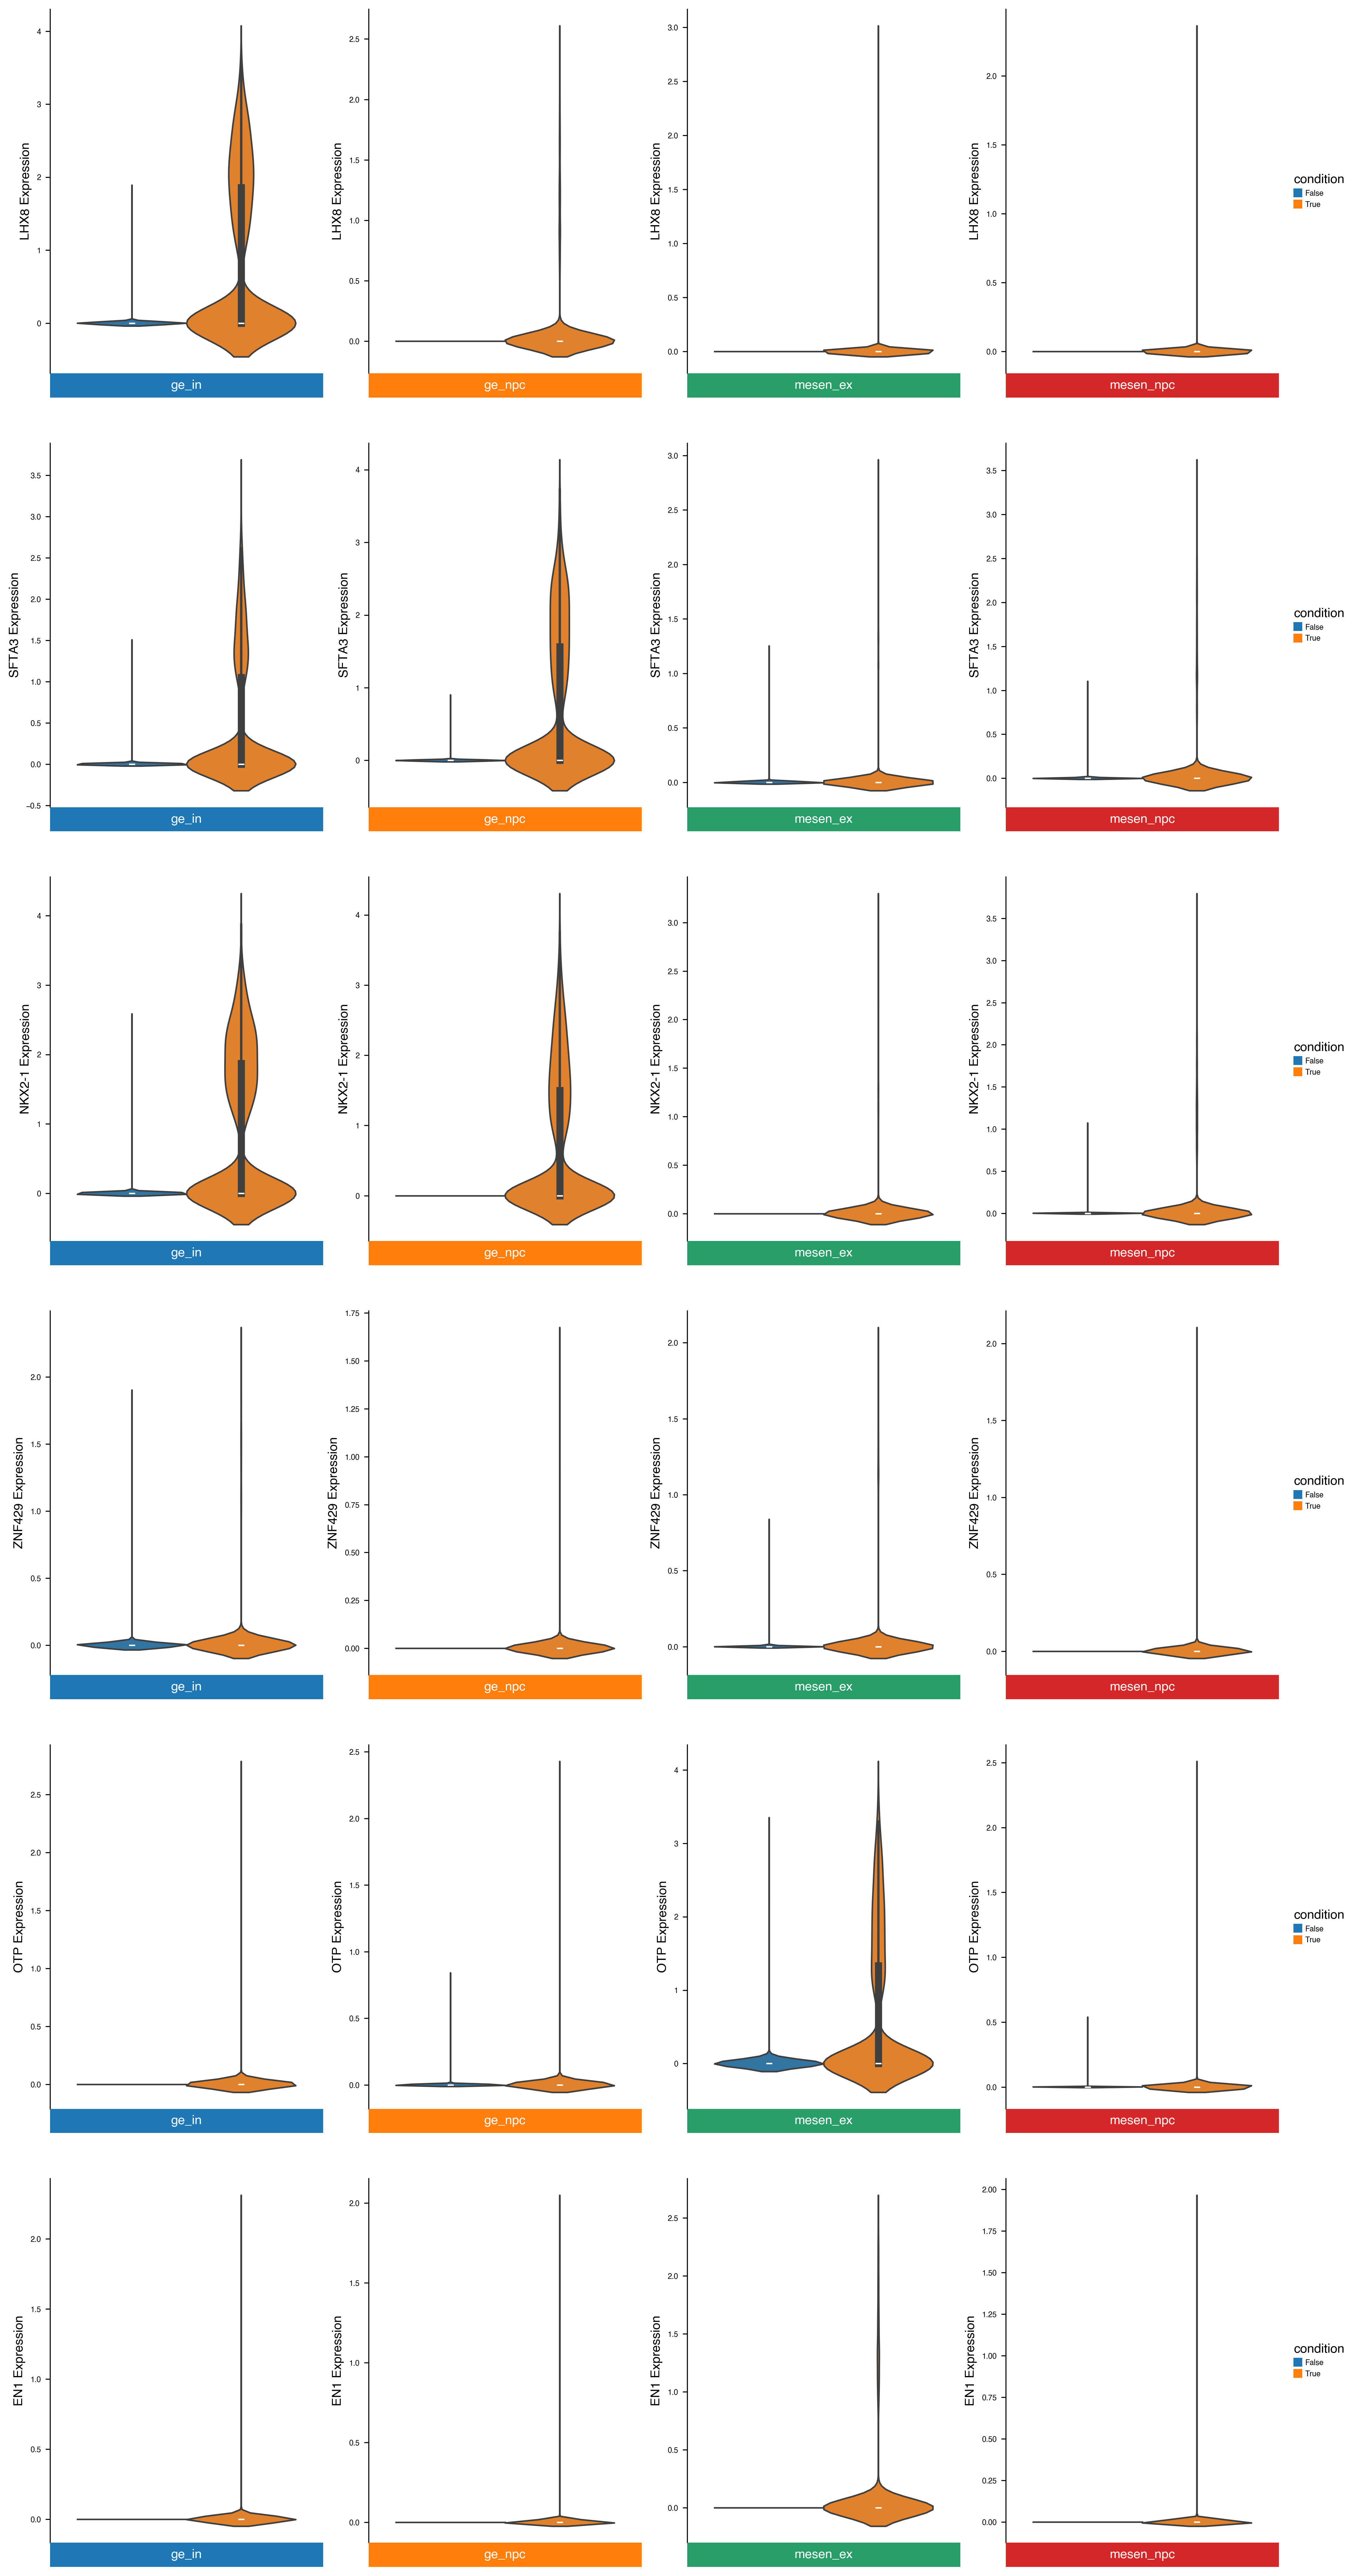

In [23]:
dx.pl.violinplot(adata, genes=common_up_genes, groupby=group_key, splitby=condition_key, use_raw=False, flip=True)

## 5. Gene Set Enrichment Analysis (GSEA)

In [24]:
# Run enrichment per group using the upregulated gene lists
background = adata.var_names.tolist()
enr_frames = []

for group, gene_dict in de_genes_dict.items():
    up_genes = gene_dict["up"]
    if len(up_genes) < 5:
        continue
    enr = dx.tl.gsea(
        up_genes,
        background=background,
    )
    enr["group"] = group
    enr["direction"] = "Up"
    enr_frames.append(enr)

    down_genes = gene_dict["down"]
    if len(down_genes) < 5:
        continue
    enr = dx.tl.gsea(
        down_genes,
        background=background,
    )
    enr["group"] = group
    enr["direction"] = "Down"
    enr_frames.append(enr)

enr_results = pd.concat(enr_frames, ignore_index=True)
print(f"Enrichment results: {len(enr_results)} terms across {enr_results['group'].nunique()} groups")

Enrichment results: 74334 terms across 4 groups


In [25]:
enr_results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,group,direction
0,gs_ind_0,AAACCAC_MIR140,1/92,0.510007,0.762220,2.109437,1.420350,EYA2,ge_in,Up
1,gs_ind_0,AAAGACA_MIR511,1/165,0.722885,0.800591,1.166138,0.378418,NR4A2,ge_in,Up
2,gs_ind_0,AAAGGGA_MIR204_MIR211,1/202,0.792691,0.830794,0.949031,0.220481,NR4A2,ge_in,Up
3,gs_ind_0,AAANWWTGC_UNKNOWN,2/158,0.343863,0.652579,2.066639,2.206159,GATA3;OTX2,ge_in,Up
4,gs_ind_0,AAAYRNCTG_UNKNOWN,2/277,0.632823,0.800591,1.162169,0.531767,DGKB;OTX2,ge_in,Up
5,gs_ind_0,AAAYWAACM_HFH4_01,3/195,0.189742,0.585149,2.370969,3.940764,OTX2;SLC39A8;GSX1,ge_in,Up
6,gs_ind_0,AACATTC_MIR4093P,2/125,0.250065,0.631699,2.626159,3.639949,SOX6;NR4A2,ge_in,Up
7,gs_ind_0,AACWWCAANK_UNKNOWN,2/129,0.261486,0.634778,2.542912,3.410994,FAM227B;OTP,ge_in,Up
8,gs_ind_0,AACYNNNNTTCCS_UNKNOWN,1/88,0.494513,0.749146,2.206610,1.553853,OTX2,ge_in,Up
9,gs_ind_0,AAGCACT_MIR520F,1/210,0.805323,0.839030,0.912172,0.197496,LHX6,ge_in,Up


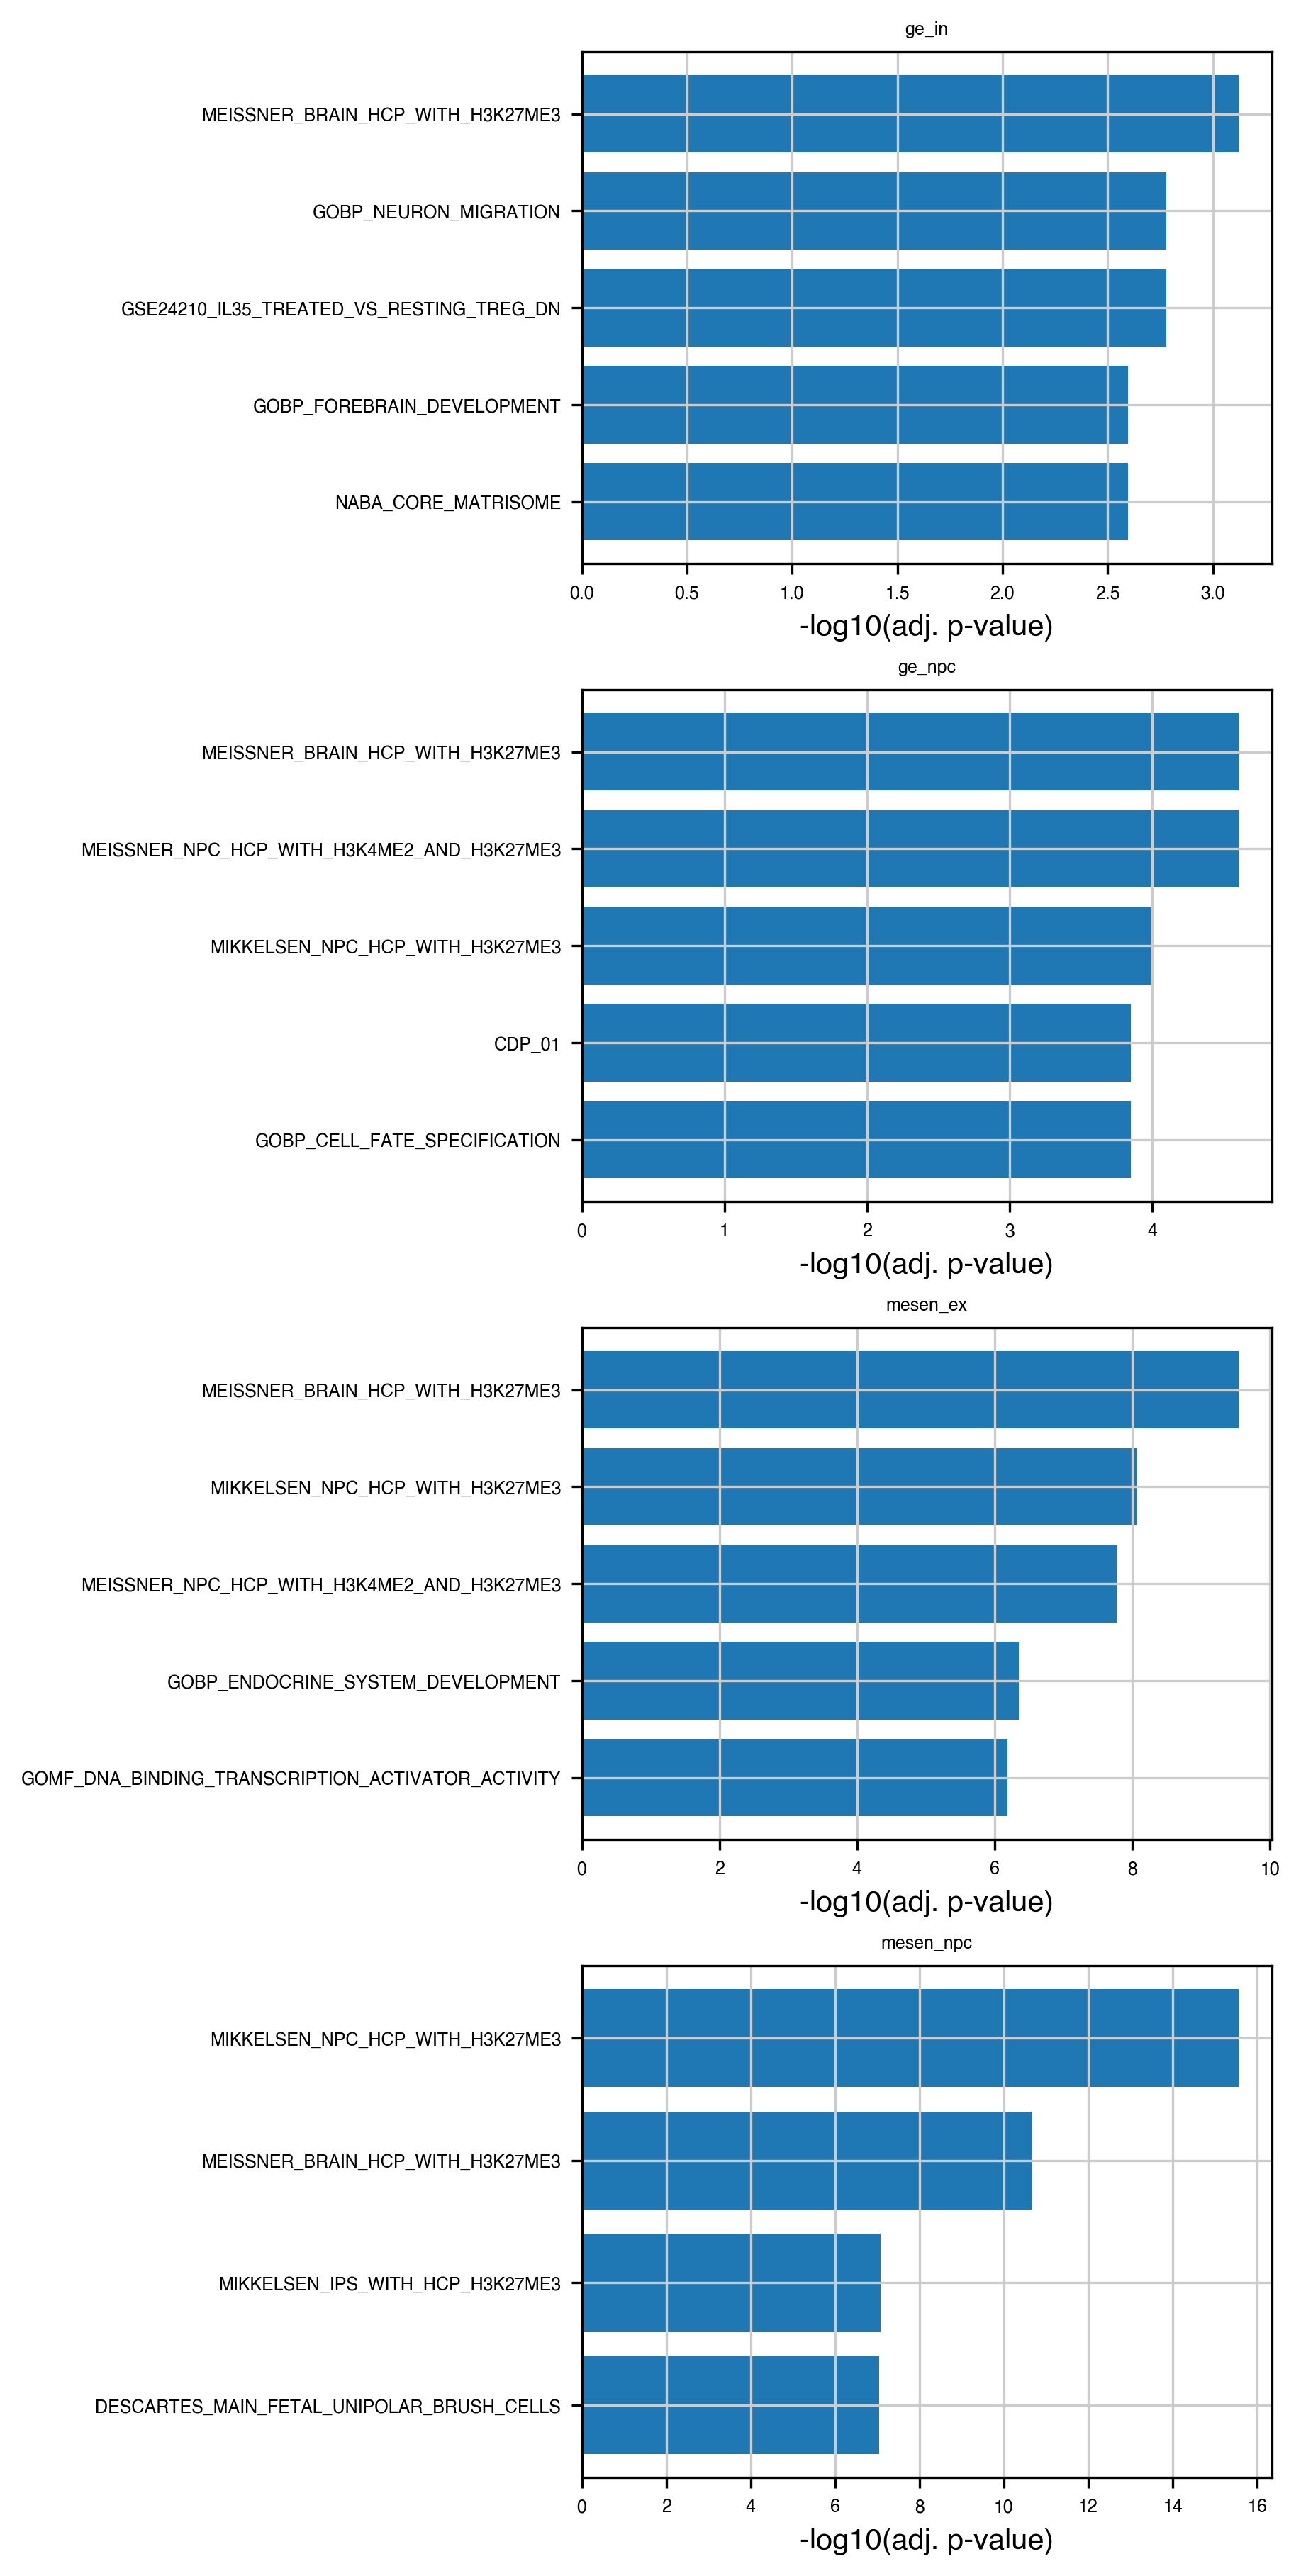

In [26]:
# Plot top enriched terms per group (barplot)
top_n = 5

fig, axs = plt.subplots(
    nrows=len(enr_results["group"].unique()),
    ncols=1,
    figsize=(6, 3 * len(enr_results["group"].unique())),
    constrained_layout=True,
)
if not hasattr(axs, "__iter__"):
    axs = [axs]

for ax, (group, sub) in zip(axs, enr_results.groupby("group")):
    top = sub.nsmallest(top_n, "Adjusted P-value")
    ax.barh(top["Term"], -np.log10(top["Adjusted P-value"]))
    ax.set_xlabel("-log10(adj. p-value)")
    ax.set_title(group)
    ax.invert_yaxis()

plt.show()